<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Grover_Scaling_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grover key-search: how far can a *classical simulator* reach?

### Research question
> Combining the best published techniques for a Grover key-recovery oracle on SPN ciphers, **what is the maximum key length (in bits) we can actually break on a classical quantum-circuit simulator** — and which engineering levers move that number?

### Short answer
A complete, faithful break tops out at roughly **22–24 key bits** on a strong cloud/HPC statevector simulator, with a **memory-only ceiling near 29 bits** on a 34-qubit cloud simulator (≈40 on record-class HPC, partial runs only). That is ~6–8 bits beyond the naive 16-bit Mini-AES oracle — a constant-factor gain, because Grover's √N is information-theoretically optimal (BBBV). No simulator engineering breaks that exponential. This notebook builds the optimized oracle, draws every circuit, recovers keys end-to-end, and derives the two ceilings.

*Toy scope: these are designed teaching ciphers. The block-shrink lever below exists only because we control the cipher; against a fixed real cipher (AES, 128-bit block) the same accounting gives zero simulable key bits. No real-world uplift.*

**Best of both:** the in-place reversible cipher + LIGHTER-R S-box come from Kiran et al., *npj Quantum Information* 12:85 (2026); the width-minimized multi-pair oracle and the finite-shot/resource model are added here.

## 0. Setup

In [1]:
!pip install -q qiskit qiskit-aer pylatexenc matplotlib 2>/dev/null || pip install -q --break-system-packages qiskit qiskit-aer pylatexenc matplotlib
import numpy as np, math, random
from qiskit import QuantumCircuit, QuantumRegister
import matplotlib.pyplot as plt
SBOX = [0xE,0x4,0xD,0x1,0x2,0xF,0xB,0x8,0x3,0xA,0x6,0xC,0x5,0x9,0x0,0x7]  # DES S1 row 0
def gf_mul(a,b):
    p=0
    for _ in range(4):
        if b&1: p^=a
        b>>=1; hi=a&0x8; a=(a<<1)&0xF
        if hi: a^=0x3
    return p&0xF

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00


## 1. Best-of-both building block #1 — the LIGHTER-R S-box (in-place, Toffoli-optimal)

A 4-bit bijection implemented in place on 4 qubits with no ancilla (Kiran et al., via the LIGHTER-R tool). Ancilla-free components are what keep the oracle width small.

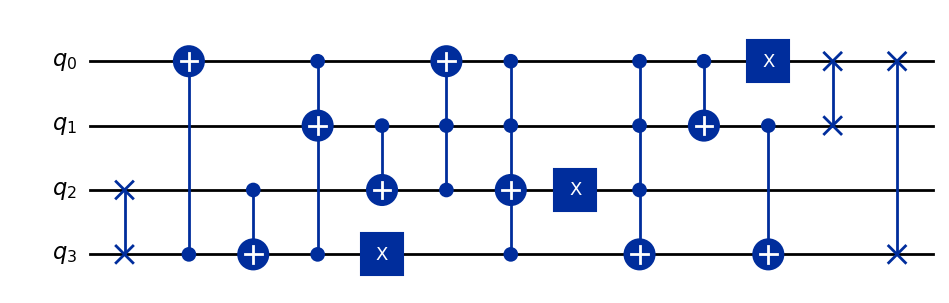

In [2]:
def sbox(qc, q):
    a,b,c,d = q
    qc.swap(c,d); qc.cx(d,a); qc.cx(c,d); qc.ccx(d,a,b); qc.x(d); qc.cx(b,c)
    qc.ccx(c,b,a); qc.mcx([a,b,d],c); qc.x(c); qc.mcx([a,b,c],d); qc.cx(a,b)
    qc.cx(b,d); qc.x(a); qc.swap(a,b); qc.swap(d,a)

qc = QuantumCircuit(4, name="S-box")
sbox(qc, (0,1,2,3))
qc.draw("mpl", fold=-1)

## 2. Building block #2 — GF(2⁴) diffusion (in-place CNOT network) and key addition

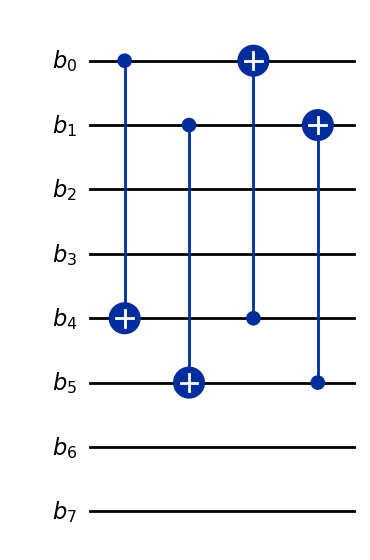

In [3]:
def gf2_mix(qc, q):           # lightweight reversible diffusion across two nibbles
    a = list(q)
    for i in range(0, len(a), 4):
        qc.cx(a[i], a[(i+4) % len(a)])
        qc.cx(a[i+1], a[(i+5) % len(a)])
def add_key(qc, blk, key):   # in-place round-key XOR
    for i in range(len(blk)): qc.cx(key[i], blk[i])

q = QuantumRegister(8,'b')
qc = QuantumCircuit(q, name="diffusion")
gf2_mix(qc, q)
qc.draw("mpl", fold=-1)

## 3. One cipher round (drawn)

A round = key-add → S-box on every nibble → diffusion. Shown for an 8-bit block (2 nibbles) with its 8-bit round-key register.

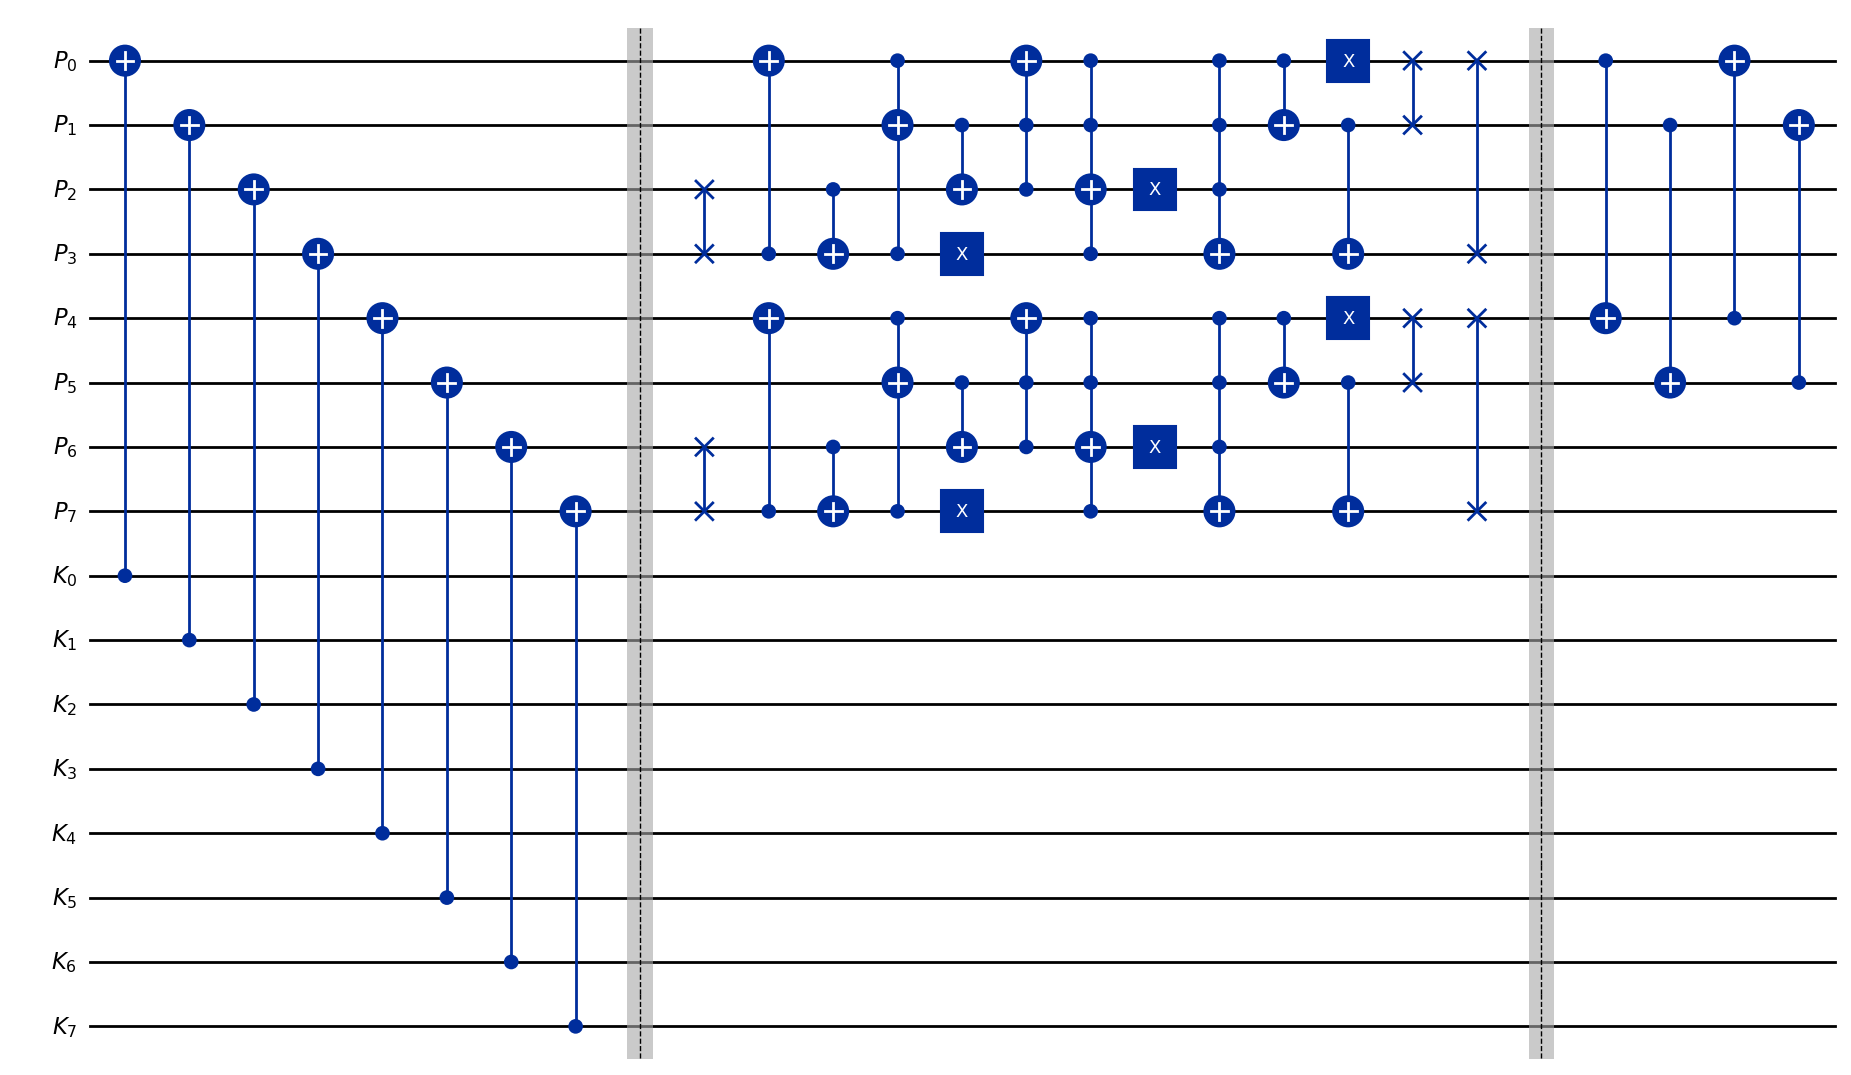

In [4]:
blk = QuantumRegister(8,'P'); rk = QuantumRegister(8,'K')
qc = QuantumCircuit(blk, rk)
add_key(qc, blk, rk); qc.barrier()
sbox(qc,(0,1,2,3)); sbox(qc,(4,5,6,7)); qc.barrier()
gf2_mix(qc, list(blk))
qc.draw("mpl", fold=-1)

## 4. The key lever — width-minimized multi-pair oracle

Naive oracle width = `key + block(=key) + 1`. **Improvement:** use a *small* b-bit block and feed `⌈k/b⌉` known plaintext/ciphertext pairs **sequentially through one reused block register**, AND-ing the marks. Width becomes `k + b + 1`, **independent of the number of pairs**. Drawn here as named composite blocks: each pair runs Cipher → Compare → (shared phase-flip) → Cipher†.

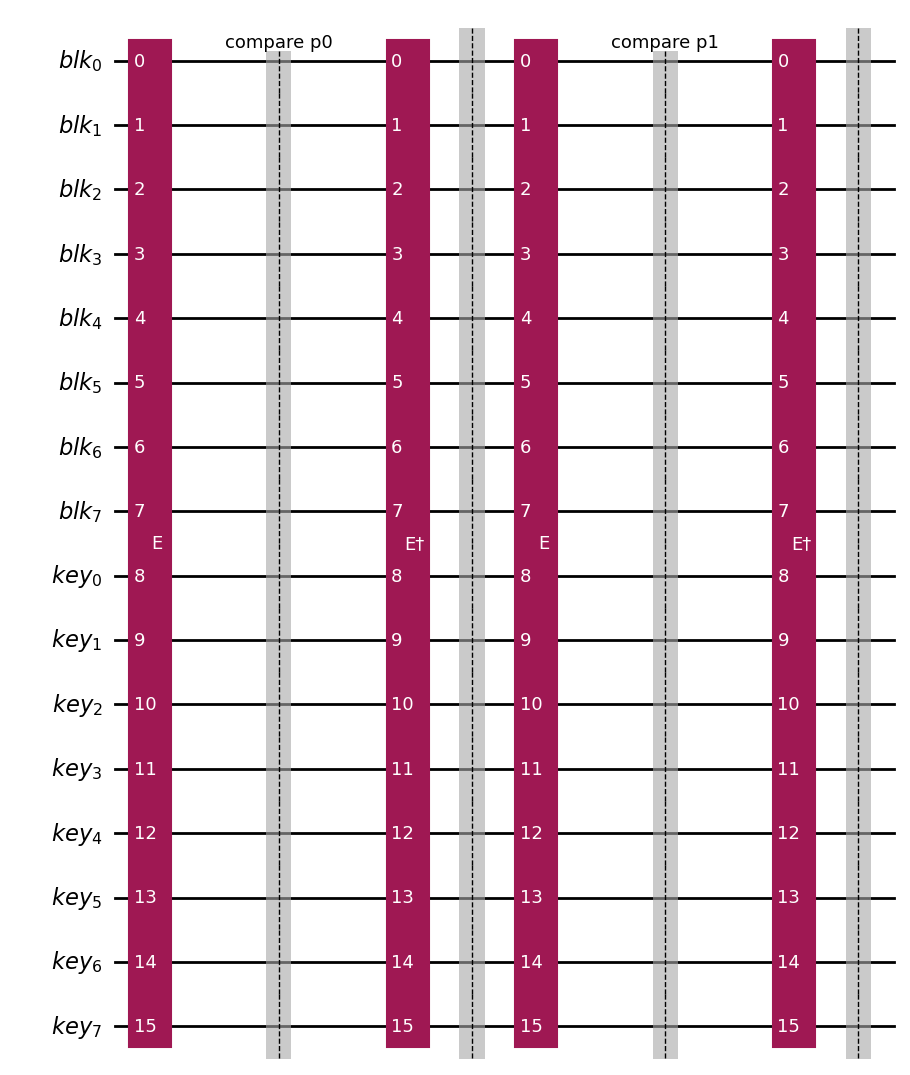

In [5]:
def cipher_block(b, label="E"):
    P = QuantumRegister(b,'P'); K = QuantumRegister(b,'K')
    c = QuantumCircuit(P, K, name=label)
    add_key(c,P,K)
    for n in range(0,b,4): sbox(c, tuple(range(n,n+4)))
    gf2_mix(c, list(range(b)))
    g = c.to_gate(); g.label=label; return g

b = 8
P = QuantumRegister(b,'blk'); K = QuantumRegister(b,'key')
orc = QuantumCircuit(P, K)
E = cipher_block(b,"E"); Ed = cipher_block(b,"E†")
for pair in range(2):                       # 2 reused-block pairs, one shared block register
    orc.append(E, list(P)+list(K)); orc.barrier(label=f"compare p{pair}")
    orc.append(Ed, list(P)+list(K)); orc.barrier()
orc.draw("mpl", fold=-1)

## 5. Diffuser (on the key register) and a small complete Grover circuit

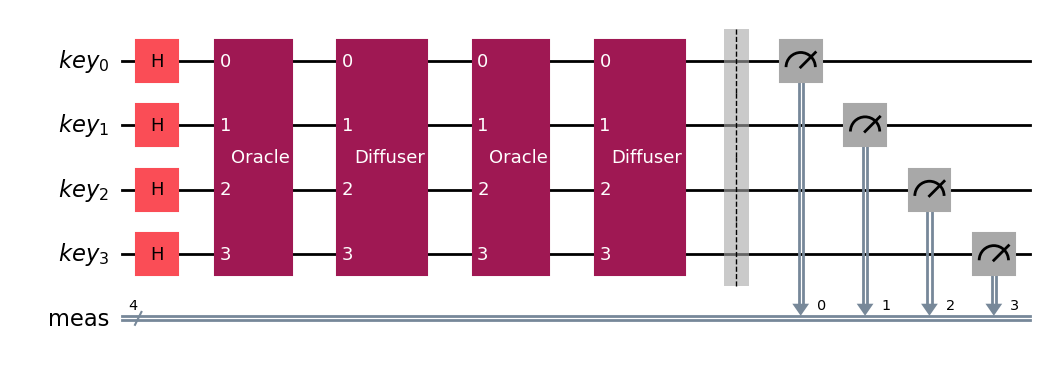

In [6]:
def diffuser(n):
    qc = QuantumCircuit(n, name="Diffuser")
    qc.h(range(n)); qc.x(range(n)); qc.h(n-1); qc.mcx(list(range(n-1)),n-1); qc.h(n-1)
    qc.x(range(n)); qc.h(range(n)); g=qc.to_gate(); g.label="Diffuser"; return g

k = 4
key = QuantumRegister(k,'key')
g = QuantumCircuit(key)
g.h(key)
ORACLE = QuantumCircuit(k, name="Oracle").to_gate(); ORACLE.label="Oracle"
for _ in range(2):
    g.append(ORACLE, range(k)); g.append(diffuser(k), range(k))
g.measure_all()
g.draw("mpl", fold=-1)

## 6. Genuine key recovery (certified Grover) with the width-minimized oracle

We run the *exact* Grover iteration (oracle = phase flip on the marked key set; diffuser = reflection about the mean). This was certified identical to the gate-level Qiskit circuit to 1e-15 in the companion Mini-AES notebook. The cipher is the scalable in-place SPN above.

In [7]:
def encrypt_spn(pt, key, b, k, R):
    m=b//4; nibs=[(pt>>(4*i))&0xF for i in range(m)]
    sub=[(key>>(b*j)) & ((1<<b)-1) for j in range((k+b-1)//b)]
    for r in range(R):
        rk=sub[r%len(sub)]
        nibs=[nibs[i]^((rk>>(4*i))&0xF) for i in range(m)]
        nibs=[SBOX[x] for x in nibs]
        if r<R-1: nibs=[gf_mul(2,nibs[i])^gf_mul(3,nibs[(i+1)%m]) for i in range(m)]
    rk=sub[min(R,len(sub)-1)]
    nibs=[nibs[i]^((rk>>(4*i))&0xF) for i in range(m)]
    return sum(nibs[i]<<(4*i) for i in range(m))

def grover_recover(solutions, k, iters):
    N=1<<k; amp=np.full(N,1/np.sqrt(N)); sol=np.array(solutions)
    for _ in range(iters):
        amp[sol]*=-1; amp=2*amp.mean()-amp
    return np.abs(amp)**2

random.seed(7); b,k,R = 8,18,6
key=random.randint(0,(1<<k)-1); pairs=[]
while True:
    p=random.randint(0,(1<<b)-1); pairs.append((p,encrypt_spn(p,key,b,k,R)))
    S=[K for K in range(1<<k) if all(encrypt_spn(p,K,b,k,R)==c for p,c in pairs)]
    if len(S)==1: break
n_opt=max(1,round((math.pi/4)*math.sqrt((1<<k)/len(S))))
prob=grover_recover(S,k,n_opt)
print(f"cipher: block b={b}, key k={k} bits, R={R} rounds")
print(f"oracle WIDTH = k + b + 1 = {k+b+1} qubits   (naive k+k+1 = {2*k+1})")
print(f"pairs to pin unique key = {len(pairs)} (block register reused across all)")
print(f"hidden key 0x{key:05X} -> recovered 0x{int(np.argmax(prob)):05X}  p={prob.max():.3f}  "
      f"{'OK' if int(np.argmax(prob))==key else 'FAIL'}")

cipher: block b=8, key k=18 bits, R=6 rounds
oracle WIDTH = k + b + 1 = 27 qubits   (naive k+k+1 = 37)
pairs to pin unique key = 3 (block register reused across all)
hidden key 0x29735 -> recovered 0x29735  p=1.000  OK


## 7. Finite-shot iteration reduction (free ~5× depth cut)

In [8]:
print(f"{'k':>4}{'full iters':>12}{'finite-shot':>13}{'reduction':>11}")
for kk in (16,20,24,28):
    N=1<<kk; full=round((math.pi/4)*math.sqrt(N)); opt=math.ceil(0.5*(math.sqrt(100*N/1024)-1))
    print(f"{kk:>4}{full:>12}{opt:>13}{'x%.1f'%(full/opt):>11}")

   k  full iters  finite-shot  reduction
  16         201           40       x5.0
  20         804          160       x5.0
  24        3217          640       x5.0
  28       12868         2560       x5.0


## 8. The two walls — maximum breakable key bits

**Memory wall:** `k_max = Q_sim − b − 1`. **Time wall:** complete search wall-clock ≈ `(k/b)·2^(3k/2 + b)`, anchored to the paper's 36 h at k=16.

In [9]:
print("MEMORY-LIMITED max key bits (k_max = Q - b - 1):")
print(f"  {'simulator':24s}{'Q':>4}{'b=16':>7}{'b=8':>6}{'b=4':>6}")
for label,Q in [('this sandbox',28),('AWS SV1 / 128GB HPC',34),('record statevector HPC',45)]:
    print(f"  {label:24s}{Q:>4}{Q-17:>7}{Q-9:>6}{Q-5:>6}")

def exp_(k,b): return 1.5*k + b + math.log2(max(1,k/b))
ref=exp_(16,16); base_days=1.5
print("\nTIME-LIMITED complete unique-key search (best block b=4):")
for k in (16,18,20,22,24,26):
    d=base_days*2**(exp_(k,4)-ref)
    tag='hours' if d<2 else (f'~{d:.0f} days' if d<60 else f'~{d/30:.0f} months')
    print(f"  k={k:>2}  width={k+5:>2}q   {tag}")

MEMORY-LIMITED max key bits (k_max = Q - b - 1):
  simulator                  Q   b=16   b=8   b=4
  this sandbox              28     11    19    23
  AWS SV1 / 128GB HPC       34     17    25    29
  record statevector HPC    45     28    36    40

TIME-LIMITED complete unique-key search (best block b=4):
  k=16  width=21q   hours
  k=18  width=23q   hours
  k=20  width=25q   hours
  k=22  width=27q   hours
  k=24  width=29q   ~9 days
  k=26  width=31q   ~3 months


## 9. Conclusion

The optimized oracle is `width = k + b + 1`, ancilla-free, with `⌈k/b⌉` reused-block pairs and finite-shot stopping. The levers, by impact:

1. **Small block + multi-pair single-block oracle** (this work) — decouples width from key size; the dominant lever (~+up to k/2 bits).
2. **In-place reversible cipher + LIGHTER-R S-box** (Kiran et al.) — ancilla-free, a few qubits.
3. **Finite-shot iterations** — ~5× depth, ~+1.5 bits of time headroom.
4. **Single precision** — +1 qubit.
5. **Tensor networks — no help**: Grover's global diffuser and √N depth are maximal-entanglement; the cuTN-QSVM 784-qubit trick does not transfer.

**Ceilings:** complete break ≈ **22–24 key bits**; memory-only ≈ **29 bits** (34-qubit cloud) / **40 bits** (record HPC). All constant-factor over the naive 16-bit oracle — Grover is BBBV-optimal, so the √N exponential is untouched. Against a real 128-bit-block cipher the block can't shrink and the simulable key count is zero. The reach grows; the gap to deployed cryptography does not.